# **Step 10: Explaining the model with SHAP**

**Question this notebook answers:** *why* does the model give a customer a high or low churn score, and which features drive churn across all customers?

## Concepts

**What SHAP does, in one example.** Think of a team that wins a prize and wants to split it fairly. Each player gets their average extra contribution over all the possible orders in which the team could have been assembled. These are **Shapley values**, from game theory. SHAP does the same for a prediction:
- the "prize" is *this customer's score minus the score of an average customer*;
- the "players" are the features.

So each feature gets a number: how much it pushed this customer's score **up** (towards churn) or **down** (towards staying).

**Three properties to remember:**
1. **Base value** = the average prediction over the training data (the "typical customer").
2. **Additivity**: base value + all SHAP values = this customer's prediction, exactly. Nothing is left unexplained.
3. **Units**: for our model, SHAP values are in **log-odds**, the scale on which logistic regression adds things up. Positive = more likely to churn. The final probability is `1 / (1 + exp(-log-odds))`.

**SHAP for a linear model is simple and exact.** For logistic regression,
`SHAP(feature) = coefficient × (customer's value − average value)`.
`LinearExplainer` computes exactly this; there is no approximation. (For trees, `TreeExplainer` needs a clever algorithm. We use it at the end to compare with XGBoost.)

**How this relates to the app's "Why this score?" table.** The app shows `coefficient × value`, which is relative to a customer whose transformed values are all 0. SHAP subtracts the *average* customer instead. The ranking of reasons is usually similar; SHAP's baseline (the average customer) is easier to explain to a business audience.

## Setup

We explain the **saved final model** (`models/churn_model.joblib`) on the **test set**: the customers the model never saw in training. We reuse `load_split()` from `train.py`, so it's exactly the same 80/20 split.

The pipeline is: collapse → add features → preprocess (scale + one-hot) → logistic regression. SHAP explains the last step, so we transform the data with every step *except* the model (`model[:-1]`). That gives the 29 columns the model actually sees.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from churn import config
from churn.modeling.predict import load_model
from churn.modeling.train import build_pipeline, load_split, make_model

warnings.filterwarnings("ignore", category=FutureWarning)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_train, X_test, y_train, y_test = load_split()
model, metadata = load_model()
cols = metadata["input_columns"]

prep, lr = model[:-1], model[-1]             # every step except the classifier / the classifier
Z_train = prep.transform(X_train[cols])      # the 29 columns the model sees (scaled + one-hot)
Z_test = prep.transform(X_test[cols])
raw_test = model[:2].transform(X_test[cols]) # readable values after collapse + add_features (has tenure_group)
proba_test = model.predict_proba(X_test[cols])[:, 1]

print(Z_train.shape, Z_test.shape)

(5634, 29) (1409, 29)


C:\Work\Github\Telco-Customer-Churn-Kaggle\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Compute the SHAP values and check additivity

The **masker** holds the background data that defines the "average customer". We pass the whole training set (`max_samples=len(Z_train)`); by default SHAP would subsample 100 rows, which is unnecessary for a linear model.

In [2]:
masker = shap.maskers.Independent(Z_train, max_samples=len(Z_train))
explainer = shap.LinearExplainer(lr, masker)
sv = explainer(Z_test)   # one row of 29 SHAP values per test customer

base = sv.base_values[0]
print(f"Base value (average log-odds): {base:.3f} -> probability {1 / (1 + np.exp(-base)):.3f}")

# Additivity check: base + sum of SHAP values must equal the model's own log-odds
logit = lr.decision_function(Z_test)
print("Max additivity error:", np.abs(sv.base_values + sv.values.sum(axis=1) - logit).max())

Base value (average log-odds): -1.574 -> probability 0.172
Max additivity error: 8.881784197001252e-16


The error is ~1e-16 (floating-point noise), so the explanation accounts for every bit of each prediction.

Note: the base value is the average **log-odds**, so its probability (~0.17) is below the 26.5% churn rate. Averaging on the log-odds scale is not the same as averaging probabilities. That's expected.

## 2. Group the one-hot columns back into features

The model sees `Contract_Month-to-month`, `Contract_One year` and `Contract_Two year` as 3 columns, but a business user thinks of one feature, *Contract*. Because SHAP values add up, we can **sum** a feature's columns to get the feature's total effect.

The matching uses the **longest feature name first**. `"tenure_group_0-6"` also starts with `"tenure_"`, so checking `tenure` first would wrongly merge the two. (This exact bug was in the app's "Why this score?" table; this notebook found it and it's now fixed in `app/streamlit_app.py`.)

In [3]:
FEATURES = sorted(config.NUM_COLS + config.CAT_COLS, key=len, reverse=True)  # longest first


def original_feature(column):
    # "cat__Contract_One year" -> "Contract", "num__tenure" -> "tenure"
    name = column.split("__", 1)[1]
    return next(f for f in FEATURES if name == f or name.startswith(f + "_"))


feature_of = [original_feature(c) for c in Z_test.columns]
shap_by_feature = pd.DataFrame(sv.values, columns=Z_test.columns, index=X_test.index).T.groupby(feature_of).sum().T

# An Explanation object for the grouped values, with readable data (e.g. "Month-to-month") for the plots
grouped = shap.Explanation(
    values=shap_by_feature.values,
    base_values=sv.base_values,
    data=raw_test[shap_by_feature.columns].astype(object).values,
    feature_names=list(shap_by_feature.columns),
)
print(shap_by_feature.shape)   # 1,409 customers x 16 features

(1409, 16)


## 3. Which features matter most overall?

**Mean |SHAP|** = on average, how far a feature moves a customer's score away from the average customer, in either direction. It measures importance, not direction.

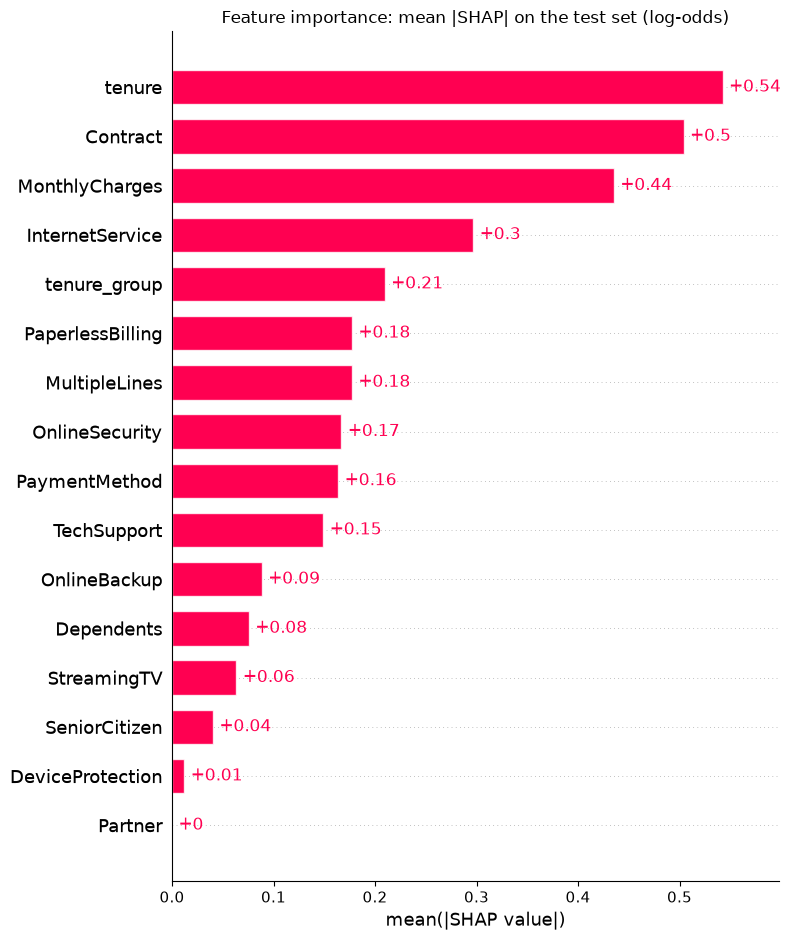

,mean |SHAP|
tenure,0.542
Contract,0.504
MonthlyCharges,0.435
InternetService,0.297
tenure_group,0.210
PaperlessBilling,0.177
MultipleLines,0.177
OnlineSecurity,0.167
PaymentMethod,0.164
TechSupport,0.149


In [4]:
shap.plots.bar(grouped, max_display=16, show=False)
plt.title("Feature importance: mean |SHAP| on the test set (log-odds)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

importance_lr = shap_by_feature.abs().mean().sort_values(ascending=False)
importance_lr.round(3).to_frame("mean |SHAP|")

**Reading it:** tenure, contract type, monthly charges and internet service dominate. Partner has 0 importance because elastic-net set its coefficient to exactly 0 (it adds nothing once Dependents and the other features are known). DeviceProtection is almost 0 for the same reason.

## 4. Direction: which values push towards churn?

The **beeswarm** plot shows one dot per customer per column. Position = SHAP value (right = towards churn); colour = the column's value (red = high, blue = low). For one-hot columns, red means "the customer has this level".

We use the 29 model columns here, not the grouped features, because the colour needs a single value per column.

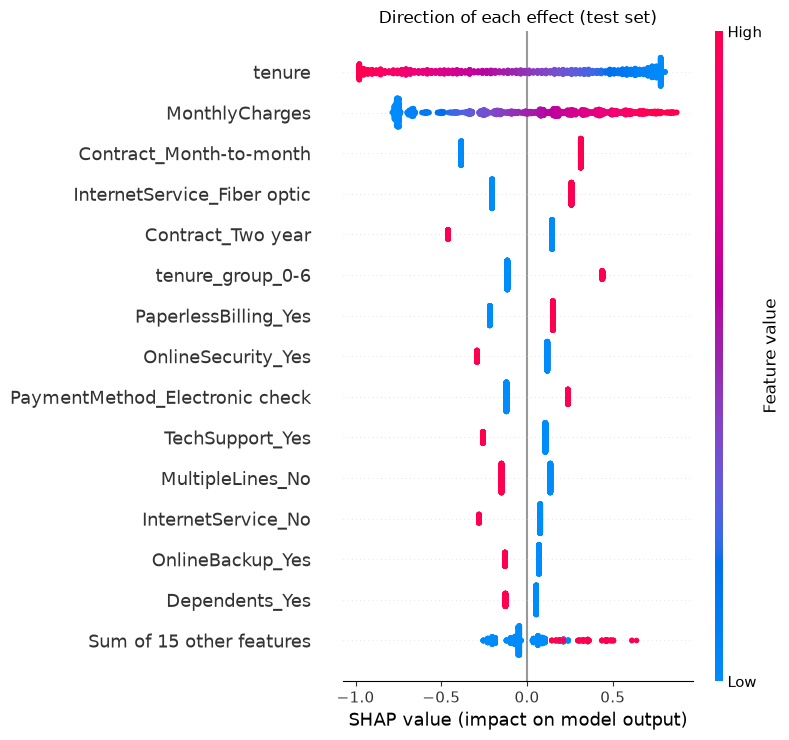

In [5]:
sv_named = shap.Explanation(
    values=sv.values, base_values=sv.base_values, data=Z_test.values,
    feature_names=[c.split("__", 1)[1] for c in Z_test.columns],
)
shap.plots.beeswarm(sv_named, max_display=15, show=False)
plt.title("Direction of each effect (test set)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

Average effect of each level of the main categorical features. This is the same information as the beeswarm, as a table you can quote.

In [6]:
rows = []
for feature in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]:
    by_level = shap_by_feature[feature].groupby(raw_test[feature]).agg(["mean", "size"])
    for level, r in by_level.iterrows():
        rows.append({"feature": feature, "level": level, "avg SHAP (log-odds)": round(r["mean"], 2), "customers": int(r["size"])})
pd.DataFrame(rows)

,feature,level,avg SHAP (log-odds),customers
0,Contract,Month-to-month,0.46,773
1,Contract,One year,-0.24,300
2,Contract,Two year,-0.84,336
3,InternetService,DSL,-0.13,484
4,InternetService,Fiber optic,0.34,613
5,InternetService,No,-0.48,312
6,PaymentMethod,Bank transfer (automatic),-0.11,300
7,PaymentMethod,Credit card (automatic),-0.14,309
8,PaymentMethod,Electronic check,0.24,474
9,PaymentMethod,Mailed check,-0.11,326


## 5. Tenure: the "first 6 months" effect

Tenure enters the model twice: raw `tenure` (a straight line in log-odds) and `tenure_group` (bins, added in feature engineering to capture the EDA's steep drop in the first months). Adding their SHAP values gives tenure's **total** effect.

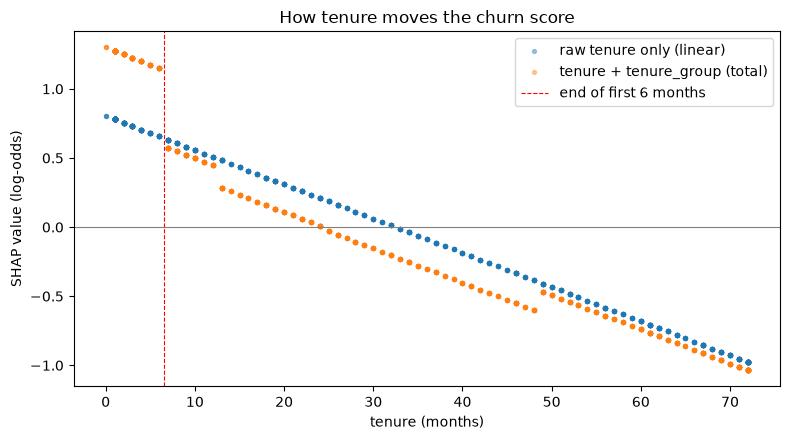

,raw tenure,tenure_group,total
tenure,,,
0-6,0.74,0.50,1.24
7-12,0.58,-0.06,0.52
13-24,0.34,-0.20,0.14
25-48,-0.09,-0.22,-0.30
49-72,-0.74,-0.06,-0.80


In [7]:
tenure_total = shap_by_feature["tenure"] + shap_by_feature["tenure_group"]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(X_test["tenure"], shap_by_feature["tenure"], s=8, alpha=0.4, label="raw tenure only (linear)")
ax.scatter(X_test["tenure"], tenure_total, s=8, alpha=0.4, label="tenure + tenure_group (total)")
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(6.5, color="red", ls="--", lw=0.8, label="end of first 6 months")
ax.set(xlabel="tenure (months)", ylabel="SHAP value (log-odds)", title="How tenure moves the churn score")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "shap_tenure_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

bands = pd.cut(X_test["tenure"], config.TENURE_BINS, labels=config.TENURE_LABELS)
pd.DataFrame({"raw tenure": shap_by_feature["tenure"], "tenure_group": shap_by_feature["tenure_group"],
              "total": tenure_total}).groupby(bands, observed=True).mean().round(2)

**Reading the plot:**
- The blue line is raw `tenure` alone: every extra month lowers the churn log-odds by the same amount.
- The orange points add `tenure_group`. In the **first 6 months** it adds about **+0.5 log-odds** (total +1.24 vs +0.74 from the line alone). That is the steep early drop the EDA found, and the reason `tenure_group` was kept (the ablation showed removing it costs ROC-AUC).
- **Side effect of binning:** the score jumps at each band edge. A customer moving from month 12 to 13 drops by about 0.2 log-odds overnight, which is not realistic behaviour. A smoother alternative (e.g. a spline on tenure) is a possible improvement, but it would add complexity for a small gain.

## 6. Explaining individual customers (waterfall plots)

A **waterfall** starts at the base value `E[f(X)]` (the average customer, bottom) and adds each feature's SHAP value until it reaches this customer's score `f(x)` (top), in log-odds. We look at three test customers:
1. the highest-scoring customer who really churned;
2. the lowest-scoring customer who really stayed;
3. a **borderline** customer, the one closest to the 0.307 threshold.

In [8]:
threshold = metadata["threshold"]
scores = pd.Series(proba_test, index=X_test.index)
picks = {
    "high_risk": scores[y_test == 1].idxmax(),
    "low_risk": scores[y_test == 0].idxmin(),
    "borderline": (scores - threshold).abs().idxmin(),
}
pos = {idx: i for i, idx in enumerate(X_test.index)}   # row label -> row number in the arrays


def show_waterfall(name):
    i = pos[picks[name]]
    print(f"{name}: P(churn) = {proba_test[i]:.3f}, actually churned = {bool(y_test.iloc[i])}, "
          f"flagged = {proba_test[i] >= threshold}")
    shap.plots.waterfall(grouped[i], max_display=10, show=False)
    plt.title(f"{name.replace('_', ' ').title()} customer: P(churn) = {proba_test[i]:.2f}")
    plt.savefig(config.FIGURES_DIR / f"shap_waterfall_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


X_test.loc[list(picks.values()), cols].T.set_axis(list(picks), axis=1)

,high_risk,low_risk,borderline
tenure,1,72,65
MonthlyCharges,95.1,19.55,106.25
SeniorCitizen,Yes,No,Yes
Partner,Yes,Yes,Yes
Dependents,No,Yes,No
MultipleLines,Yes,No,Yes
InternetService,Fiber optic,No,Fiber optic
OnlineSecurity,No,No internet service,No
OnlineBackup,No,No internet service,Yes
DeviceProtection,No,No internet service,Yes


high_risk: P(churn) = 0.887, actually churned = True, flagged = True


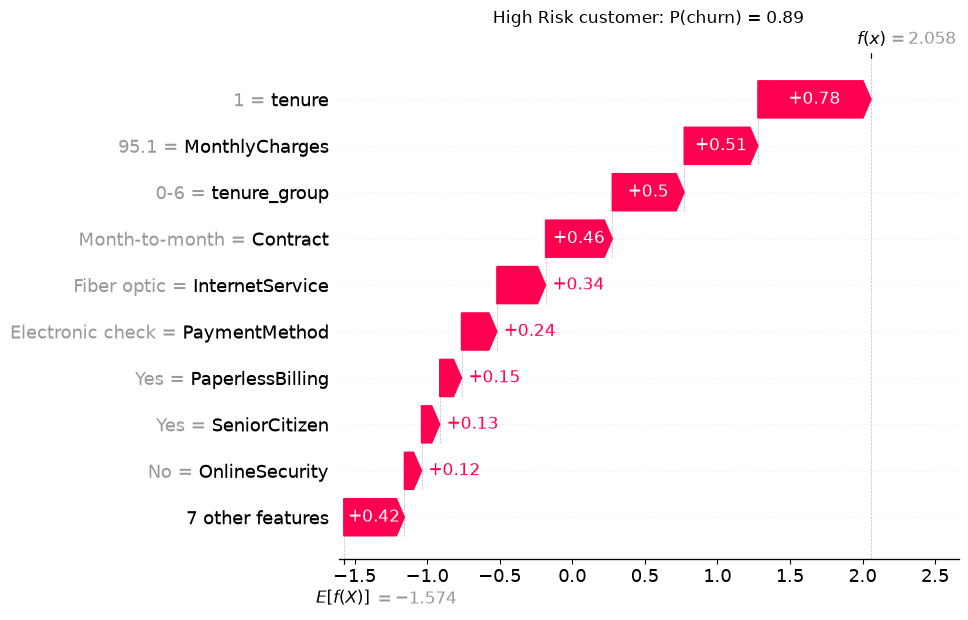

In [9]:
show_waterfall("high_risk")

low_risk: P(churn) = 0.006, actually churned = False, flagged = False


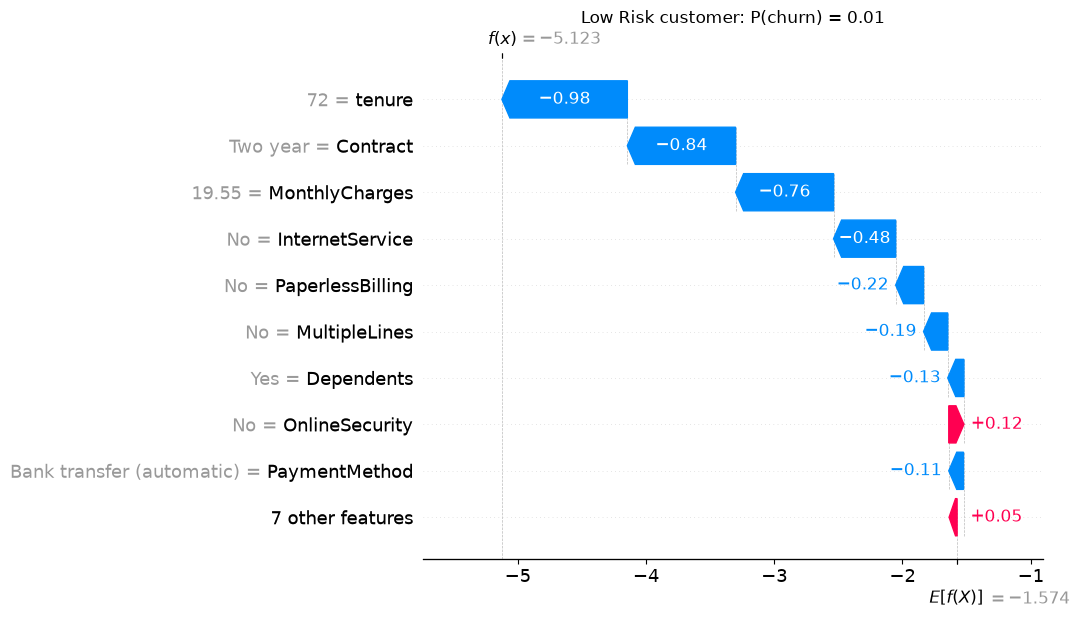

In [10]:
show_waterfall("low_risk")

borderline: P(churn) = 0.307, actually churned = True, flagged = True


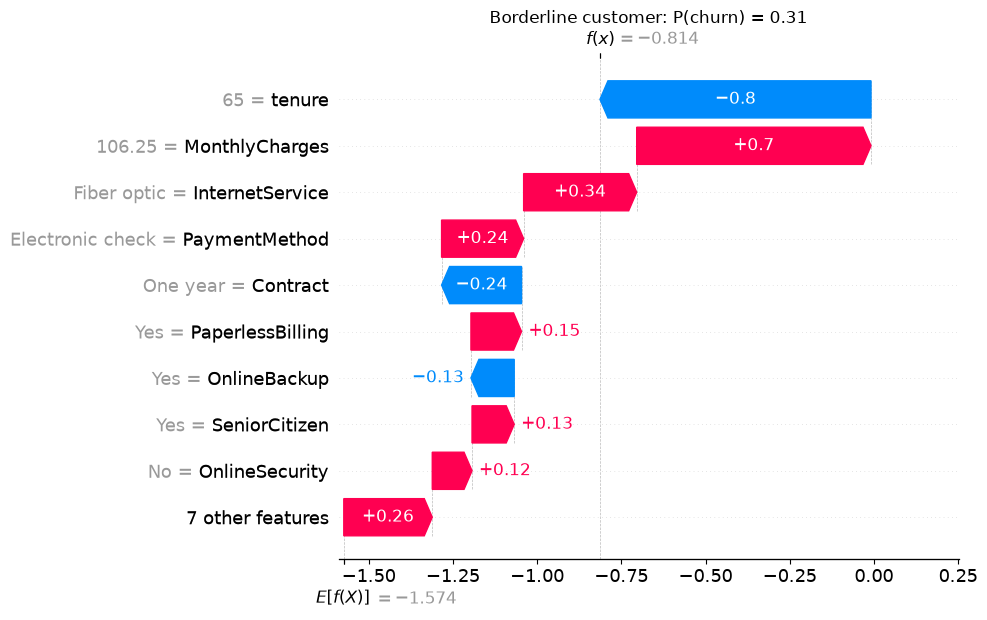

In [11]:
show_waterfall("borderline")

**How to read these for a retention team:**
- **High-risk customer (P = 0.89, churned):** 1 month in, month-to-month, fibre optic at $95/month, electronic check, no online security. Every bar points towards churn. Several of them are things the business can change: offer a 1-year contract, bundle online security or tech support, move them to automatic payment.
- **Low-risk customer (P = 0.006, stayed):** 72 months, two-year contract, no internet, $20/month. Every bar points towards staying. No offer needed.
- **Borderline customer (P = 0.307, churned):** a loyal customer (65 months, −0.8) on a one-year contract, but with a **$106 bill (+0.7)**, fibre optic (+0.34) and electronic check (+0.24). The loyalty is almost cancelled out by the price. The 0.307 threshold flags them; the default 0.5 would have missed them, and they did churn. Long-standing, high-paying customers like this are the most valuable to keep, so a price-focused offer fits here.

In [12]:
# Tuned in 5_tuning_final.ipynb (Optuna, 100 trials, CV ROC-AUC 0.8507)
xgb_params = {"n_estimators": 750, "max_depth": 2, "learning_rate": 0.015929600655741186,
              "subsample": 0.6194597052072689, "colsample_bytree": 0.5892499114485255,
              "min_child_weight": 8, "reg_lambda": 7.8940601629996605}
xgb_pipe = build_pipeline(make_model("xgb", xgb_params), "tree").fit(X_train, y_train)

Zx_test = xgb_pipe[:-1].transform(X_test)
sv_xgb = shap.TreeExplainer(xgb_pipe[-1])(Zx_test)
xgb_by_feature = (pd.DataFrame(sv_xgb.values, columns=Zx_test.columns).T
                  .groupby([original_feature(c) for c in Zx_test.columns]).sum().T)
importance_xgb = xgb_by_feature.abs().mean()

compare = pd.DataFrame({"LR mean |SHAP|": importance_lr, "XGB mean |SHAP|": importance_xgb})
compare["LR rank"] = compare.iloc[:, 0].rank(ascending=False).astype(int)
compare["XGB rank"] = compare.iloc[:, 1].rank(ascending=False).astype(int)
print("Spearman rank correlation:", round(compare["LR mean |SHAP|"].corr(compare["XGB mean |SHAP|"], method="spearman"), 2))
compare.sort_values("LR rank").round(3)

Spearman rank correlation: 0.9


,LR mean |SHAP|,XGB mean |SHAP|,LR rank,XGB rank
tenure,0.542,0.529,1,2
Contract,0.504,0.651,2,1
MonthlyCharges,0.435,0.223,3,4
InternetService,0.297,0.431,4,3
tenure_group,0.210,0.103,5,10
PaperlessBilling,0.177,0.150,6,7
MultipleLines,0.177,0.152,7,6
OnlineSecurity,0.167,0.124,8,8
PaymentMethod,0.164,0.187,9,5
TechSupport,0.149,0.093,10,11


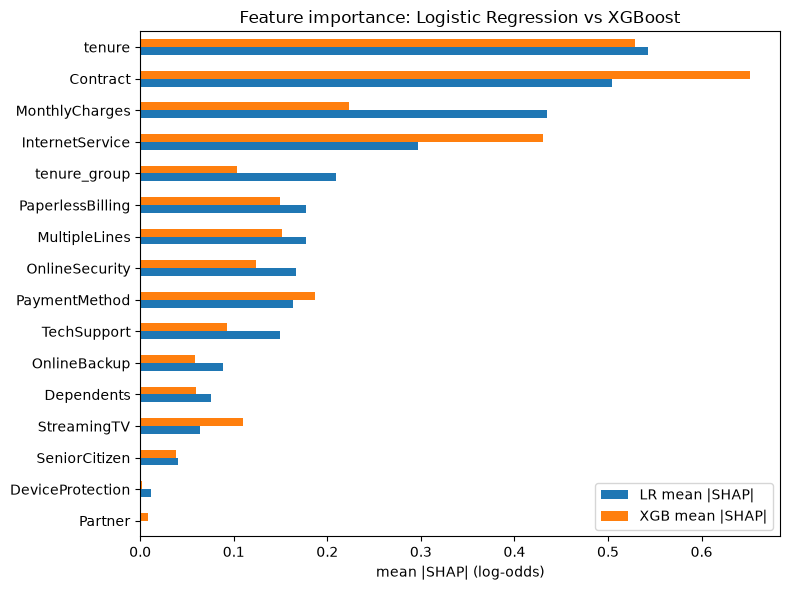

In [13]:
ax = compare.sort_values("LR mean |SHAP|")[["LR mean |SHAP|", "XGB mean |SHAP|"]].plot.barh(figsize=(8, 6))
ax.set(xlabel="mean |SHAP| (log-odds)", title="Feature importance: Logistic Regression vs XGBoost")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "shap_lr_vs_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Conclusions

**1. What drives churn (mean |SHAP|, test set).** Tenure is the strongest driver, followed by contract type, monthly charges and internet service. Counting `tenure` and `tenure_group` together, tenure is clearly first.

**2. Direction, in numbers you can quote** (average SHAP per level, in log-odds):

| Feature | Raises churn risk | Lowers churn risk |
|---|---|---|
| Contract | Month-to-month **+0.46** | One year −0.24, Two year **−0.84** |
| Tenure | First 6 months **+1.24** (line + bin) | 49–72 months **−0.80** |
| InternetService | Fiber optic **+0.34** | No internet −0.48, DSL −0.13 |
| PaymentMethod | Electronic check **+0.24** | Automatic bank/card −0.11 / −0.14 |
| OnlineSecurity / TechSupport | Not having them +0.12 / +0.11 | Having them **−0.29 / −0.26** |
| MonthlyCharges | Higher bills | Lower bills |

Example: month-to-month vs two-year is a gap of 0.46 + 0.84 = 1.30 log-odds, i.e. e^1.30 ≈ **3.7× the odds of churning**. That is the same figure as in the README, now confirmed by SHAP.

**3. It agrees with the EDA.** Every EDA insight shows up: month-to-month contracts, the first months of tenure, fibre optic, electronic check, and the protective effect of online security and tech support. One addition: **MonthlyCharges** is the 3rd most important feature. Higher bills raise risk, even after accounting for fibre optic.

**4. It agrees with XGBoost.** The two models rank the features with a Spearman correlation of **0.90**, and the top 4 are the same (tenure, contract, monthly charges, internet service). The main difference: XGBoost relies less on `tenure_group` (rank 10 vs 5), because trees can find the early-tenure jump from raw `tenure` on their own; the linear model needs the bin to see it. When two very different models point to the same drivers, those drivers are very likely real patterns in the data.

**5. Business actions this supports:**
- Move month-to-month customers to 1- or 2-year contracts (the biggest controllable lever).
- Focus onboarding on the **first 6 months**.
- Bundle online security / tech support, especially for fibre-optic customers.
- Encourage automatic payment instead of electronic check.
- Watch long-standing customers with high bills: loyalty does not fully protect them (see the borderline customer).

**6. Limits (worth saying in an interview):**
- SHAP explains **the model**, not the world. These are associations, not causes: giving someone tech support will not necessarily make them stay.
- Correlated features share credit. MonthlyCharges and fibre optic move together, and SHAP with an independent masker splits the effect between them somewhat arbitrarily.
- The app's "Why this score?" table uses `coefficient × value` (relative to all-zero inputs), not SHAP (relative to the average customer). The top reasons are usually the same; SHAP's baseline is easier to explain.